# 02 Literary Text Processing

## Goal
This notebook processes the prepared literary text of *Invisible Cities* and converts it into a structured dataset for later stages of the project.

The notebook will:
- load the prepared text file
- split the text by `[CITY_GROUP: ...]` markers
- build structured text units
- clean each text unit
- extract keywords
- assign simple emotion labels
- save processed outputs for later notebooks

## Step 1 — Import libraries
Import the libraries needed for file handling, regular expressions, text cleaning, keyword extraction, and dataframe construction.

In [54]:
from pathlib import Path
import json
import re
from collections import Counter
import pandas as pd

## Step 2 — Load the project config
Load the project paths defined earlier so the notebook can reuse the same folder structure.

In [55]:
PROJECT_ROOT = Path.cwd().resolve().parent
CONFIG_PATH = PROJECT_ROOT / "src" / "project_config.json"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

RAW_LITERARY_DIR = Path(config["raw_literary_dir"])
CLEANED_LITERARY_DIR = Path(config["cleaned_literary_dir"])
PROCESSED_LITERARY_DIR = Path(config["processed_literary_dir"])
OUTPUT_TABLES_DIR = Path(config["output_tables_dir"])

print("Raw literary directory:", RAW_LITERARY_DIR)
print("Processed literary directory:", PROCESSED_LITERARY_DIR)

Raw literary directory: D:\Work\Workspace\Projects\Python\data-driven-surface\data\raw\literary_text
Processed literary directory: D:\Work\Workspace\Projects\Python\data-driven-surface\data\processed\literary_text


## Step 3 — Load the prepared literary text
Read the cleaned `.txt` file prepared in Notebook 02a.

In [56]:
text_files = list(RAW_LITERARY_DIR.glob("*.txt"))
text_files

[WindowsPath('D:/Work/Workspace/Projects/Python/data-driven-surface/data/raw/literary_text/invisible_cities.txt')]

## Step 4 — Select the literary text file
If there is only one text file in the folder, select it automatically.

In [57]:
if len(text_files) == 0:
    raise FileNotFoundError(
        "No .txt file found in data/raw/literary_text/. "
        "Please run 02a_text_preparation.ipynb first."
    )

selected_text_path = text_files[0]
print("Selected text file:", selected_text_path.name)

Selected text file: invisible_cities.txt


## Step 5 — Read the text content
Load the full prepared literary text as a string.

In [58]:
with open(selected_text_path, "r", encoding="utf-8") as f:
    literary_text = f.read()

print(literary_text[:3000])

Kublai Khan does not necessarily believe everything Marco Polo says when he describes the cities visited on his expeditions, but the emperor of the Tartars does continue listening to the young Venetian with greater attention and curiosity than he shows any other messenger or explorer of his. In the lives of emperors there is a moment which follows pride in the boundless extension of the territories we have conquered, and the melancholy and relief of knowing we shall soon give up any thought of knowing and understanding them. There is a sense of emptiness that comes over us at evening, with the odour of the elephants after the rain and the sandalwood ashes growing cold in the braziers, a dizziness that makes rivers and mountains tremble on the fallow curves of the planispheres where they are portrayed, and rolls up, one after the other, the despatches announcing to us the collapse of the last enemy troops, from defeat to defeat, and flakes the wax of the seals of obscure kings who besee

## Step 6 — Define text-unit splitting logic
The prepared text contains structural markers such as:

`[CITY_GROUP: Cities & Memory 1]`

These markers will be used to split the book into meaningful text units.

In [59]:
pattern = r"\[CITY_GROUP:\s*(.*?)\]"

parts = re.split(pattern, literary_text)

print("Number of split parts:", len(parts))
print("Preview of first few parts:")
print(parts[:5])

Number of split parts: 91
Preview of first few parts:
['Kublai Khan does not necessarily believe everything Marco Polo says when he describes the cities visited on his expeditions, but the emperor of the Tartars does continue listening to the young Venetian with greater attention and curiosity than he shows any other messenger or explorer of his. In the lives of emperors there is a moment which follows pride in the boundless extension of the territories we have conquered, and the melancholy and relief of knowing we shall soon give up any thought of knowing and understanding them. There is a sense of emptiness that comes over us at evening, with the odour of the elephants after the rain and the sandalwood ashes growing cold in the braziers, a dizziness that makes rivers and mountains tremble on the fallow curves of the planispheres where they are portrayed, and rolls up, one after the other, the despatches announcing to us the collapse of the last enemy troops, from defeat to defeat, an

## Step 7 — Convert split parts into structured records
Each record will contain:
- the city group label
- the corresponding text content

In [60]:
records = []

# re.split returns:
# [intro_text, group_1, text_1, group_2, text_2, ...]
intro_text = parts[0].strip()

for i in range(1, len(parts), 2):
    city_group = parts[i].strip()
    unit_text = parts[i + 1].strip() if i + 1 < len(parts) else ""

    records.append({
        "unit_id": len(records) + 1,
        "city_group": city_group,
        "text": unit_text
    })

unit_df = pd.DataFrame(records)

print("Intro text preview:")
print(intro_text[:1000])

print("\nStructured text units:")
unit_df.head()

Intro text preview:
Kublai Khan does not necessarily believe everything Marco Polo says when he describes the cities visited on his expeditions, but the emperor of the Tartars does continue listening to the young Venetian with greater attention and curiosity than he shows any other messenger or explorer of his. In the lives of emperors there is a moment which follows pride in the boundless extension of the territories we have conquered, and the melancholy and relief of knowing we shall soon give up any thought of knowing and understanding them. There is a sense of emptiness that comes over us at evening, with the odour of the elephants after the rain and the sandalwood ashes growing cold in the braziers, a dizziness that makes rivers and mountains tremble on the fallow curves of the planispheres where they are portrayed, and rolls up, one after the other, the despatches announcing to us the collapse of the last enemy troops, from defeat to defeat, and flakes the wax of the seals of obs

,unit_id,city_group,text
0,1,Cities & Memory 1,Leaving there and proceeding for three days to...
1,2,Cities & Memory 2,When a man rides a long time through wild regi...
2,3,Cities & Desire 1,There are two ways of describing the city of D...
3,4,Cities & Memory 3,"In vain, great-hearted Kublai, shall I attempt..."
4,5,Cities & Desire 2,"At the end of three days, moving southward, yo..."


## Step 8 — Inspect the structured text units
Check the number of extracted units and preview the first few entries.

In [61]:
print("Number of text units:", len(unit_df))
unit_df[["unit_id", "city_group"]].head(10)

Number of text units: 45


,unit_id,city_group
0,1,Cities & Memory 1
1,2,Cities & Memory 2
2,3,Cities & Desire 1
3,4,Cities & Memory 3
4,5,Cities & Desire 2
5,6,Cities & Signs 1
6,7,Cities & Memory 4
7,8,Cities & Desire 3
8,9,Cities & Signs 2
9,10,Thin Cities 1


## Step 9 — Define a stronger text cleaning function
This cleaning step is for NLP processing rather than EPUB preparation.

It removes:
- extra punctuation noise
- repeated whitespace
- unusual symbols
while keeping the text readable.

In [62]:
def clean_unit_text(text: str) -> str:
    text = text.replace("\xa0", " ")
    text = re.sub(r"[“”]", '"', text)
    text = re.sub(r"[‘’]", "'", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{2,}", "\n", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

## Step 10 — Apply text cleaning to each unit
Create a cleaned version of the text for further analysis.

In [63]:
unit_df["clean_text"] = unit_df["text"].apply(clean_unit_text)
unit_df["char_count"] = unit_df["clean_text"].str.len()
unit_df["word_count"] = unit_df["clean_text"].str.split().str.len()

unit_df.head()

,unit_id,city_group,text,clean_text,char_count,word_count
0,1,Cities & Memory 1,Leaving there and proceeding for three days to...,Leaving there and proceeding for three days to...,745,136
1,2,Cities & Memory 2,When a man rides a long time through wild regi...,When a man rides a long time through wild regi...,742,131
2,3,Cities & Desire 1,There are two ways of describing the city of D...,There are two ways of describing the city of D...,1288,221
3,4,Cities & Memory 3,"In vain, great-hearted Kublai, shall I attempt...","In vain, great-hearted Kublai, shall I attempt...",1684,306
4,5,Cities & Desire 2,"At the end of three days, moving southward, yo...","At the end of three days, moving southward, yo...",1368,248


## Step 11 — Define stopwords and filtering rules
This step removes common function words, articles, pronouns, and other low-information words.

This is especially important for preventing words such as:
- the
- a
- he
- she
from appearing in the final keyword list.

In [64]:
stopwords = {
    # articles / determiners
    "the", "a", "an", "this", "that", "these", "those",

    # pronouns
    "he", "she", "it", "they", "we", "you", "i",
    "him", "her", "them", "us", "me",
    "his", "hers", "their", "our", "your", "my",
    "himself", "herself", "itself", "themselves",

    # auxiliary / modal verbs
    "is", "are", "was", "were", "be", "been", "being",
    "am", "do", "does", "did", "done",
    "have", "has", "had",
    "will", "would", "shall", "should", "can", "could", "may", "might", "must",

    # conjunctions / prepositions / connectors
    "and", "or", "but", "if", "then", "than", "because", "while",
    "of", "in", "on", "at", "by", "for", "to", "from", "with", "without",
    "into", "onto", "over", "under", "through", "between", "among",
    "as", "about", "before", "after", "during", "across", "against",
    "towards", "toward", "out", "back",

    # adverbs / misc common words
    "not", "no", "so", "too", "very", "more", "most", "less",
    "there", "here", "where", "when", "why", "how",
    "all", "any", "each", "every", "some", "such",
    "only", "also", "just", "even", "still", "already",
    "once", "now",

    # question / pronoun-like
    "who", "what", "which", "whom",

    # speech / narrative filler
    "said", "says", "say", "told",

    # generic nouns / low-information words
    "city", "cities", "man", "people", "thing", "things",
    "day", "days", "time", "times",

    # generic verbs
    "go", "goes", "went", "come", "comes", "came",
    "see", "saw", "seen",
    "make", "made",
    "take", "took",

    # literary leftovers
    "one", "two", "first", "second", "like", "its"
}

## Step 12 — Define tokenization and keyword extraction
This function extracts content-heavy keywords from each text unit.

In [65]:
def tokenize_words(text: str):
    tokens = re.findall(r"\b[a-zA-Z']+\b", text.lower())
    return tokens

def extract_keywords(text: str, top_n: int = 12):
    tokens = tokenize_words(text)

    number_words = {
        "one", "two", "three", "four", "five", "six",
        "seven", "eight", "nine", "ten",
        "hundred", "thousand"
    }

    weak_words = {
    "many", "some", "other", "same", "long", "much",
    "very", "even", "still", "also"
    }


    filtered_tokens = []
    for token in tokens:
        token = token.strip("'")

        if len(token) <= 3:
            continue
        if token in stopwords:
            continue
        if token in number_words:
            continue
        if token in weak_words:
            continue
        if token.isdigit():
            continue
        if token.endswith("'s"):
            continue

        filtered_tokens.append(token)

    counts = Counter(filtered_tokens)
    return [word for word, _ in counts.most_common(top_n)]

In [66]:
unit_df["keywords"] = unit_df["clean_text"].apply(lambda x: extract_keywords(x, top_n=12))
unit_df[["unit_id", "city_group", "keywords"]].head(10)

,unit_id,city_group,keywords
0,1,Cities & Memory 1,"[evening, leaving, proceeding, east, reach, di..."
1,2,Cities & Memory 2,"[isidora, spiral, young, rides, wild, regions,..."
2,3,Cities & Desire 1,"[dorothea, quarters, morning, desert, caravan,..."
3,4,Cities & Memory 3,"[past, zaira, tell, steps, streets, telling, h..."
4,5,Cities & Desire 2,"[anastasia, desire, sometimes, agate, onyx, ch..."
5,6,Cities & Signs 1,"[sign, tamara, trees, stones, streets, thick, ..."
6,7,Cities & Memory 4,"[zora, point, streets, memory, houses, along, ..."
7,8,Cities & Desire 3,"[camel, thinks, desert, despina, ship, differe..."
8,9,Cities & Signs 2,"[zirma, blind, black, girl, puma, redundant, r..."
9,10,Thin Cities 1,"[marco, past, khan, polo, place, great, kublai..."


## Step 13 — Extract keywords for each text unit
Generate a keyword list for each city-text unit.

In [67]:
unit_df["keywords"] = unit_df["clean_text"].apply(lambda x: extract_keywords(x, top_n=12))
unit_df[["unit_id", "city_group", "keywords"]].head(10)

,unit_id,city_group,keywords
0,1,Cities & Memory 1,"[evening, leaving, proceeding, east, reach, di..."
1,2,Cities & Memory 2,"[isidora, spiral, young, rides, wild, regions,..."
2,3,Cities & Desire 1,"[dorothea, quarters, morning, desert, caravan,..."
3,4,Cities & Memory 3,"[past, zaira, tell, steps, streets, telling, h..."
4,5,Cities & Desire 2,"[anastasia, desire, sometimes, agate, onyx, ch..."
5,6,Cities & Signs 1,"[sign, tamara, trees, stones, streets, thick, ..."
6,7,Cities & Memory 4,"[zora, point, streets, memory, houses, along, ..."
7,8,Cities & Desire 3,"[camel, thinks, desert, despina, ship, differe..."
8,9,Cities & Signs 2,"[zirma, blind, black, girl, puma, redundant, r..."
9,10,Thin Cities 1,"[marco, past, khan, polo, place, great, kublai..."


## Step 14 — Define a simple emotion lexicon
This is a lightweight baseline for identifying tone and emotion patterns in each unit.

In [68]:
emotion_lexicon = {
    "joy": {
        "joy", "happy", "light", "bright", "golden", "beautiful", "laughter", "delight", "pleasure"
    },
    "sadness": {
        "sad", "melancholy", "sorrow", "loss", "cold", "empty", "lonely", "silent", "fading", "despair"
    },
    "fear": {
        "fear", "danger", "dark", "shadow", "uncertain", "fragile", "collapse", "ruin", "enemy", "death"
    },
    "awe": {
        "wonder", "majestic", "tower", "vast", "sublime", "marvel", "precious", "infinite", "glory", "vision"
    },
    "desire": {
        "desire", "dream", "longing", "wish", "memory", "love", "envy", "hope", "yearning", "imagined"
    }
}

## Step 15 — Define the emotion scoring functions
Each text unit will receive:
- emotion counts
- a dominant emotion label

In [69]:
def score_emotions(text: str, lexicon: dict):
    tokens = tokenize_words(text)
    scores = {}
    for emotion, vocab in lexicon.items():
        scores[emotion] = sum(1 for token in tokens if token in vocab)
    return scores

def get_dominant_emotion(score_dict: dict):
    if not score_dict:
        return "neutral"

    max_score = max(score_dict.values())
    if max_score == 0:
        return "neutral"

    top = [k for k, v in score_dict.items() if v == max_score]
    return top[0]

## Step 16 — Apply emotion analysis
Assign emotion scores and a dominant emotion to each city-text unit.

In [70]:
unit_df["emotion_scores"] = unit_df["clean_text"].apply(lambda x: score_emotions(x, emotion_lexicon))
unit_df["dominant_emotion"] = unit_df["emotion_scores"].apply(get_dominant_emotion)

emotion_df = pd.json_normalize(unit_df["emotion_scores"])
unit_df = pd.concat([unit_df.drop(columns=["emotion_scores"]), emotion_df], axis=1)

unit_df.head()

,unit_id,city_group,text,clean_text,char_count,word_count,keywords,dominant_emotion,joy,sadness,fear,awe,desire
0,1,Cities & Memory 1,Leaving there and proceeding for three days to...,Leaving there and proceeding for three days to...,745,136,"[evening, leaving, proceeding, east, reach, di...",joy,2,0,0,1,1
1,2,Cities & Memory 2,When a man rides a long time through wild regi...,When a man rides a long time through wild regi...,742,131,"[isidora, spiral, young, rides, wild, regions,...",desire,0,0,0,0,1
2,3,Cities & Desire 1,There are two ways of describing the city of D...,There are two ways of describing the city of D...,1288,221,"[dorothea, quarters, morning, desert, caravan,...",desire,0,0,0,0,1
3,4,Cities & Memory 3,"In vain, great-hearted Kublai, shall I attempt...","In vain, great-hearted Kublai, shall I attempt...",1684,306,"[past, zaira, tell, steps, streets, telling, h...",neutral,0,0,0,0,0
4,5,Cities & Desire 2,"At the end of three days, moving southward, yo...","At the end of three days, moving southward, yo...",1368,248,"[anastasia, desire, sometimes, agate, onyx, ch...",desire,1,0,0,0,4


## Step 17 — Preview keyword and emotion results
Inspect whether the extracted features look reasonable.

In [71]:
unit_df[[
    "unit_id",
    "city_group",
    "keywords",
    "dominant_emotion"
]].head(15)

,unit_id,city_group,keywords,dominant_emotion
0,1,Cities & Memory 1,"[evening, leaving, proceeding, east, reach, di...",joy
1,2,Cities & Memory 2,"[isidora, spiral, young, rides, wild, regions,...",desire
2,3,Cities & Desire 1,"[dorothea, quarters, morning, desert, caravan,...",desire
3,4,Cities & Memory 3,"[past, zaira, tell, steps, streets, telling, h...",neutral
4,5,Cities & Desire 2,"[anastasia, desire, sometimes, agate, onyx, ch...",desire
5,6,Cities & Signs 1,"[sign, tamara, trees, stones, streets, thick, ...",sadness
6,7,Cities & Memory 4,"[zora, point, streets, memory, houses, along, ...",desire
7,8,Cities & Desire 3,"[camel, thinks, desert, despina, ship, differe...",neutral
8,9,Cities & Signs 2,"[zirma, blind, black, girl, puma, redundant, r...",desire
9,10,Thin Cities 1,"[marco, past, khan, polo, place, great, kublai...",desire


## Step 18 — Visualise keyword frequency
This step aggregates the extracted keywords across all text units and visualises the most frequent terms.

The chart helps identify dominant spatial and semantic themes in the literary text, and can support later image scraping and prompt construction.

In [72]:
from collections import Counter
import matplotlib.pyplot as plt

# Flatten all keyword lists into one list
all_keywords = []
for keywords in unit_df["keywords"]:
    all_keywords.extend(keywords)

keyword_counts = Counter(all_keywords)
top_keywords = keyword_counts.most_common(20)

freq_df = pd.DataFrame(top_keywords, columns=["keyword", "count"])
freq_df

,keyword,count
0,another,10
1,streets,7
2,different,7
3,marco,7
4,inhabitants,6
5,tell,5
6,form,5
7,khan,5
8,place,5
9,great,5


## Step 19 — Plot the top keyword frequencies
Plot the 20 most frequent keywords extracted from the literary units.

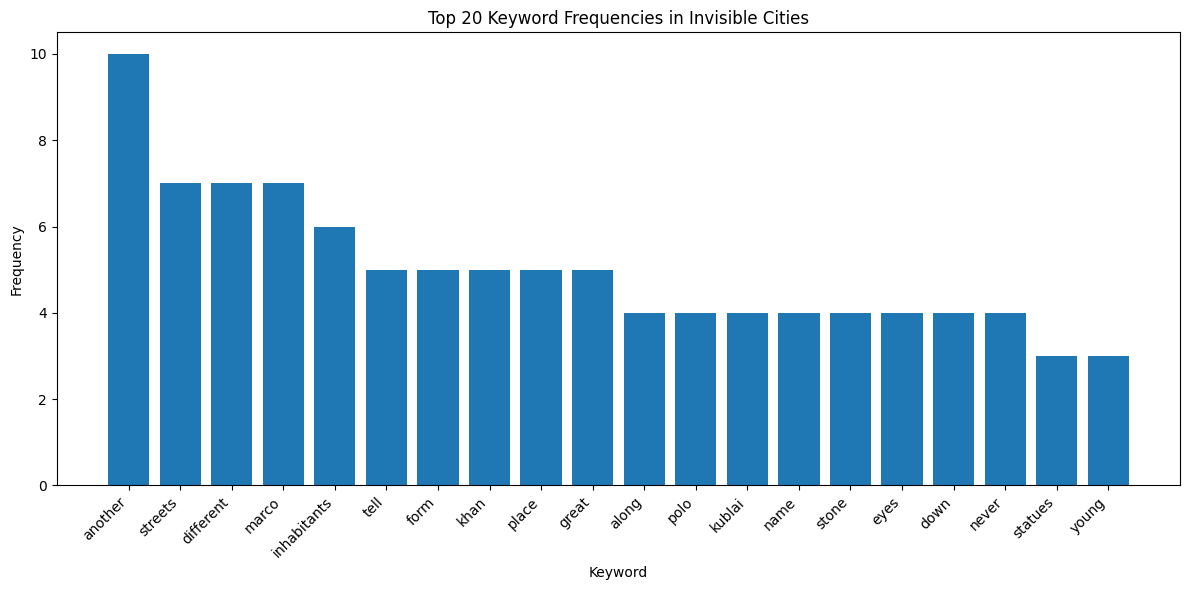

In [73]:
plt.figure(figsize=(12, 6))
plt.bar(freq_df["keyword"], freq_df["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.title("Top 20 Keyword Frequencies in Invisible Cities")
plt.tight_layout()
plt.show()

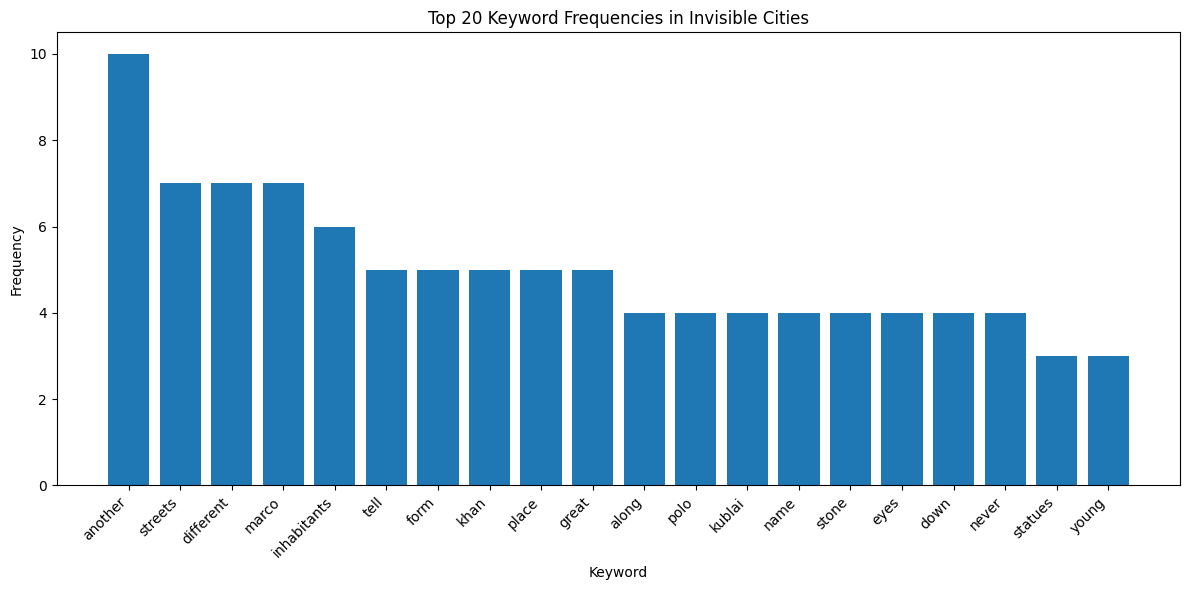

Saved figure to: D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\figures\keyword_frequency.png


In [74]:
keyword_fig_path = OUTPUT_TABLES_DIR.parent / "figures" / "keyword_frequency.png"

plt.figure(figsize=(12, 6))
plt.bar(freq_df["keyword"], freq_df["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.title("Top 20 Keyword Frequencies in Invisible Cities")
plt.tight_layout()
plt.savefig(keyword_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", keyword_fig_path)

## Step 20 — Save the cleaned unit text
Save a text-only cleaned version for future reference.

In [75]:
cleaned_units_txt_path = CLEANED_LITERARY_DIR / "invisible_cities_units_cleaned.txt"

with open(cleaned_units_txt_path, "w", encoding="utf-8") as f:
    for row in unit_df.itertuples(index=False):
        f.write(f"[CITY_GROUP: {row.city_group}]\n")
        f.write(row.clean_text + "\n\n")

print("Saved cleaned unit text to:", cleaned_units_txt_path)

Saved cleaned unit text to: D:\Work\Workspace\Projects\Python\data-driven-surface\data\cleaned\literary_text\invisible_cities_units_cleaned.txt


## Step 21 — Save the structured dataframe as CSV
Export the processed literary units for later notebooks.

In [76]:
processed_csv_path = PROCESSED_LITERARY_DIR / "invisible_cities_units_processed.csv"
unit_df.to_csv(processed_csv_path, index=False, encoding="utf-8-sig")

print("Saved processed CSV to:", processed_csv_path)

Saved processed CSV to: D:\Work\Workspace\Projects\Python\data-driven-surface\data\processed\literary_text\invisible_cities_units_processed.csv


## Step 22 — Save a JSON version
This JSON file is useful for prompt generation and later AI workflows.

In [77]:
processed_json_path = PROCESSED_LITERARY_DIR / "invisible_cities_units_processed.json"

records = unit_df.to_dict(orient="records")

with open(processed_json_path, "w", encoding="utf-8") as f:
    json.dump(records, f, indent=4, ensure_ascii=False)

print("Saved processed JSON to:", processed_json_path)

Saved processed JSON to: D:\Work\Workspace\Projects\Python\data-driven-surface\data\processed\literary_text\invisible_cities_units_processed.json


## Step 23 — Summary statistics
Preview the distribution of text length, keywords, and dominant emotions.

In [78]:
print("Number of units:", len(unit_df))
print("\nDominant emotion distribution:")
print(unit_df["dominant_emotion"].value_counts())

print("\nExample keywords:")
for _, row in unit_df[["city_group", "keywords"]].head(5).iterrows():
    print(f"{row['city_group']}: {row['keywords']}")

Number of units: 45

Dominant emotion distribution:
dominant_emotion
joy        14
desire     12
neutral     8
fear        6
sadness     4
awe         1
Name: count, dtype: int64

Example keywords:
Cities & Memory 1: ['evening', 'leaving', 'proceeding', 'east', 'reach', 'diomira', 'sixty', 'silver', 'domes', 'bronze', 'statues', 'gods']
Cities & Memory 2: ['isidora', 'spiral', 'young', 'rides', 'wild', 'regions', 'feels', 'desire', 'finally', 'buildings', 'staircases', 'encrusted']
Cities & Desire 1: ['dorothea', 'quarters', 'morning', 'desert', 'caravan', 'routes', 'ways', 'describing', 'aluminium', 'towers', 'rise', 'walls']
Cities & Memory 3: ['past', 'zaira', 'tell', 'steps', 'streets', 'telling', 'height', 'lamppost', 'railing', 'guttering', 'gunboat', 'dock']
Cities & Desire 2: ['anastasia', 'desire', 'sometimes', 'agate', 'onyx', 'chrysoprase', 'desires', 'form', 'moving', 'southward', 'upon', 'concentric']


## Step 24 — Summary
The literary text has now been:
- split into structured city-text units
- cleaned for NLP analysis
- annotated with keywords
- annotated with simple emotion labels
- exported as CSV and JSON

Next notebook:
- `03_image_scraping.ipynb`